#0. Importar librerias y configurar entorno

In [1]:
 # Importacion de librerias necesarias para el procesamiento de datos y creacion de modelos

import tensorflow as tf
import keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist


ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

In [2]:
# Verificar disponibilidad de GPU
gpu_available = tf.config.list_physical_devices('GPU')

if gpu_available:
    print("GPU disponible. Usando:", gpu_available[0].name)
    # Configurar el crecimiento de memoria para optimizar el uso de VRAM
    tf.config.experimental.set_memory_growth(gpu_available[0], True)
else:
    print("No se encontro GPU. Usando CPU.")

GPU disponible. Usando: /physical_device:GPU:0


## 1. Cargar el conjunto de datos MNIST

In [3]:
# Carga del conjunto de datos MNIST dividido en conjuntos de entrenamiento y prueba
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [4]:
# Verificacion de las dimensiones de los datos cargados
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (60000, 28, 28)
Forma de y_train: (60000,)
Forma de X_test: (10000, 28, 28)
Forma de y_test: (10000,)


## 2. Previsualización de las imágenes

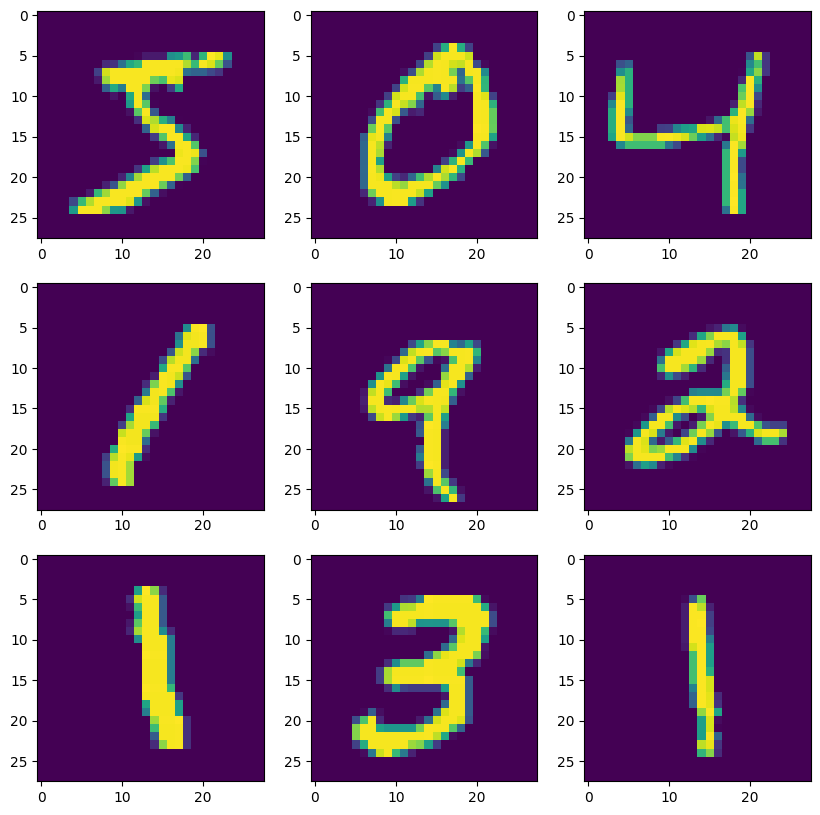

In [5]:
# Funcion para normalizar y redimensionar imagenes
def preprocess(image, label, img_size=(224, 224)):
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Seleccion de una muestra de 9 imagenes para visualizacion
imagenes_de_prueba = X_train[:9], y_train[:9]

# Configuracion de la visualizacion de la muestra
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagenes_de_prueba[0][i])

## 3. Crear una Red Neuronal Convolucional (CNN)

In [6]:
from tensorflow.keras import layers, models

# Arquitectura de la red neuronal convolucional para MNIST
model = models.Sequential([
    # Primera capa convolucional y reduccion por promedio
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.AvgPool2D((2, 2)),
    # Capa Dropout para evitar el sobreajuste
    layers.Dropout(0.5),
    # Segunda capa convolucional
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.AvgPool2D((2, 2)),
    # Aplanado de la salida para conectar con capas densas
    layers.Flatten(),
    # Capas densas de procesamiento
    layers.Dense(1024, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    # Capa de clasificacion final para 10 digitos
    layers.Dense(10, activation='softmax')
])

# Compilacion con optimizador adam y funcion de perdida
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Resumen de los parametros y capas del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,639,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,316,938 (8.84 MB)

 Trainable params: 2,316,938 (8.84 MB)

 Non-trainable params: 0 (0.00 B)

Este es un modelo CNN básico. Para entrenarlo, necesitarías aplicar el preprocesamiento a todo el dataset de entrenamiento y validación, y luego usar `model.fit()`.

## 4. Entrenamiento y Evaluación

In [7]:
# Entrenamiento del modelo con el dataset MNIST
# Se utiliza un batch_size de 32 para procesar las imagenes en grupos
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9410 - loss: 0.2892 - val_accuracy: 0.9827 - val_loss: 0.0598
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9767 - loss: 0.0791 - val_accuracy: 0.9860 - val_loss: 0.0467
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9811 - loss: 0.0649 - val_accuracy: 0.9844 - val_loss: 0.0558
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9829 - loss: 0.0612 - val_accuracy: 0.9868 - val_loss: 0.0460
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9851 - loss: 0.0538 - val_accuracy: 0.9893 - val_loss: 0.0389
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9865 - loss: 0.0474 - val_accuracy: 0.9891 - val_loss: 0.0401
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9888 - loss: 0.0414 - val_accuracy: 0.9890 - val_loss: 0.0441
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9880 - loss: 0.0442 

In [8]:
## Evaluar con el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"Precisión en el conjunto de prueba: {test_acc * 100:.2f}%")

313/313 - 1s - 2ms/step - accuracy: 0.9856 - loss: 0.0607
Precisión en el conjunto de prueba: 98.56%


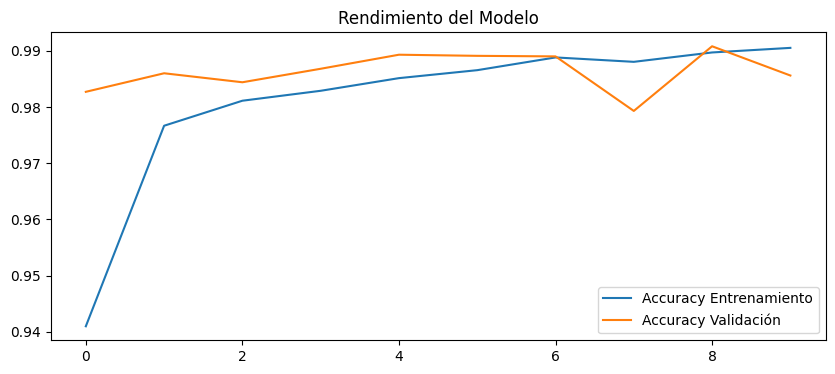

In [9]:
# Gráfica de resultados
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Accuracy Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy Validación')
plt.title("Rendimiento del Modelo")
plt.legend()
plt.show()

## Ejemplo con imagenes satelitales a color (EuroSat Dataset)

In [10]:
import tensorflow as tf
import pathlib
import os
import requests
import zipfile

# Rutas de almacenamiento para el dataset EuroSAT
dataset_url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
zip_path = "/content/EuroSAT.zip"
extract_path = "/content/EuroSAT_Data"

# Descarga del dataset omitiendo la verificacion SSL
print("Descargando dataset EuroSAT...")
response = requests.get(dataset_url, verify=False, stream=True)
with open(zip_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

# Extraccion de archivos del zip
print("Extrayendo archivos...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Definicion de la ruta de los datos extraidos
data_dir = pathlib.Path(extract_path) / "2750"

# Carga de datasets de entrenamiento y validacion desde directorio
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(64, 64),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(64, 64),
    batch_size=32
)

print(f"Dataset cargado con las clases: {train_ds.class_names}")

Descargando dataset EuroSAT...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'madm.dfki.de'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Extrayendo archivos...
Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Dataset cargado con las clases: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


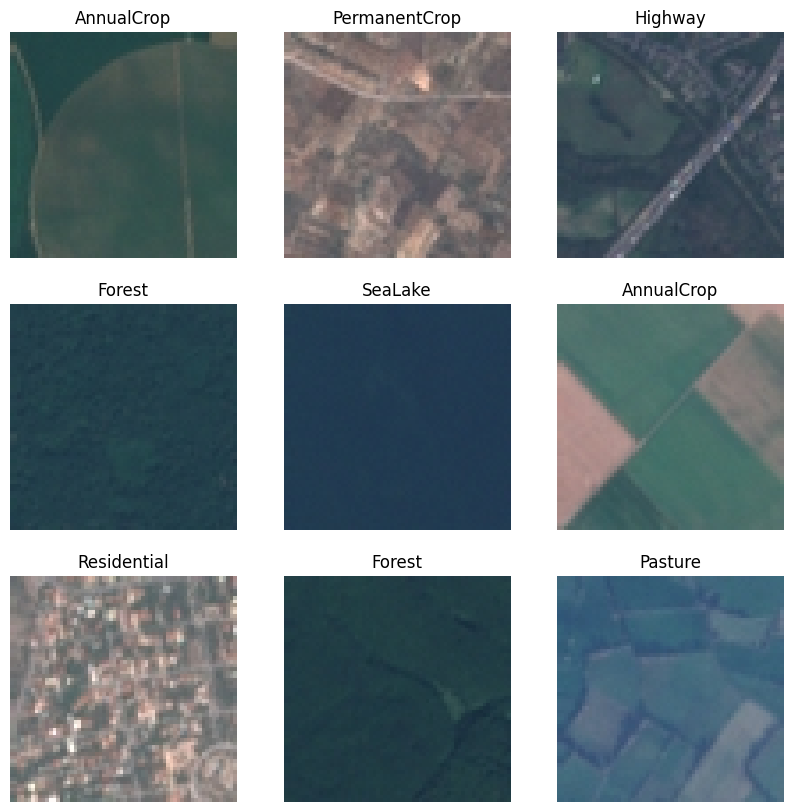

In [11]:
# Visualizar algunas imágenes del dataset EuroSAT
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [12]:
# Definir modelo CNN para EuroSAT (64x64 RGB 3 canales de color)
from tensorflow.keras import layers, models

model_eurosat = models.Sequential([
    layers.Rescaling(1./255, input_shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(train_ds.class_names), activation='softmax')
])

model_eurosat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_eurosat.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
## Entrenar y validar el modelo
history_eurosat = model_eurosat.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5168 - loss: 1.2605 - val_accuracy: 0.6950 - val_loss: 0.8549
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7120 - loss: 0.7910 - val_accuracy: 0.7570 - val_loss: 0.6818
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7733 - loss: 0.6312 - val_accuracy: 0.8226 - val_loss: 0.4998
Epoch 4/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8070 - loss: 0.5389 - val_accuracy: 0.7994 - val_loss: 0.5755
Epoch 5/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8311 - loss: 0.4722 - val_accuracy: 0.8402 - val_loss: 0.4460
Epoch 6/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8542 - loss: 0.4077 - val_accuracy: 0.7678 - val_loss: 0.6455
Epoch 7/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8669 - loss: 0.3688 - val_accuracy: 0.8369 - val_loss: 0.4741
Epoch 8/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8866 - loss: 0.3164 - val_acc

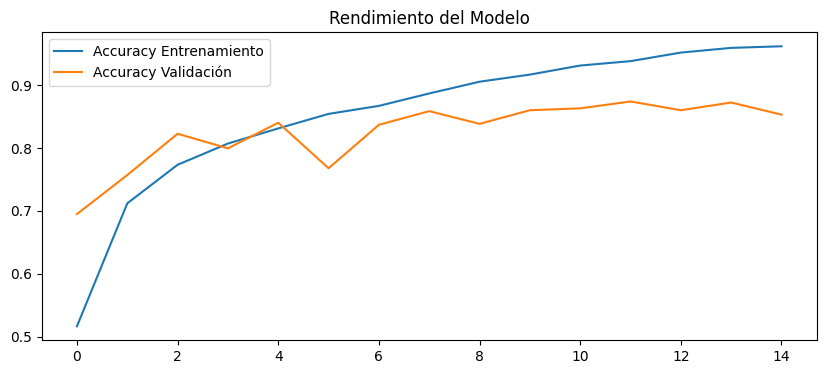

In [14]:
# Gráfica de resultados
plt.figure(figsize=(10,4))
plt.plot(history_eurosat.history['accuracy'], label='Accuracy Entrenamiento')
plt.plot(history_eurosat.history['val_accuracy'], label='Accuracy Validación')
plt.title("Rendimiento del Modelo")
plt.legend()
plt.show()

In [15]:
## Evaluar el modelo con los datos de validación

test_loss, test_acc = model_eurosat.evaluate(val_ds)
print(f"Precisión en el conjunto de validación: {test_acc * 100:.2f}%")


169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8530 - loss: 0.6055
Precisión en el conjunto de validación: 85.30%


### ¿Qué es el Dropout y cómo optimizar la red?

*   **Dropout:** Es una técnica de regularización. Al desactivar neuronas al azar, evitamos que la red 'memorice' el ruido de las imágenes de entrenamiento.
*   **Optimización:** Para mejorar la precisión que obtuvimos, podemos usar:
    *   **Aumento de datos (Data Augmentation):** Generar nuevas versiones de las imágenes.
    *   **Normalización por lotes (BatchNormalization):** Mantiene los valores en escalas similares dentro de la red.
    *   **Callbacks:** Como `EarlyStopping` para no sobre-entrenar.

In [29]:
# Aumento de datos moderado para preservar la estructura de la imagen satelital
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# Arquitectura robusta y estable para EuroSAT
model_optimized = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    # Bloque 1: Captura de texturas basicas
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Bloque 2: Caracteristicas intermedias
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.3),

    # Bloque 3: Caracteristicas complejas
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.GlobalAveragePooling2D(), # Mas robusto que Flatten

    # Clasificador final
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(train_ds.class_names), activation='softmax')
])

# Configuracion del optimizador con Learning Rate reducido
model_optimized.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callback de detencion temprana
callback = tf.keras.callbacks.EarlyStopping(
    monitor='accuracy',
    patience=5,
    restore_best_weights=True
)

print("Iniciando entrenamiento con arquitectura estabilizada y LR reducido...")
history_opt = model_optimized.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[callback]
)

Iniciando entrenamiento con arquitectura estabilizada y LR reducido...
Epoch 1/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.6059 - loss: 1.2375 - val_accuracy: 0.6904 - val_loss: 0.9143
Epoch 2/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.6950 - loss: 0.9261 - val_accuracy: 0.6937 - val_loss: 1.0195
Epoch 3/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7212 - loss: 0.8174 - val_accuracy: 0.6243 - val_loss: 1.4529
Epoch 4/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.7560 - loss: 0.7216 - val_accuracy: 0.6524 - val_loss: 1.3165
Epoch 5/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.7714 - loss: 0.6652 - val_accuracy: 0.6278 - val_loss: 1.5248
Epoch 6/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.7896 - loss: 0.6213 - val_accuracy: 0.8298 - val_loss: 0.5185
Epoch 7/25
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8054 - loss: 0.5716 - val_accuracy: 0.7876 - val_loss: 0.6691
Epoch 8/25
675/675 

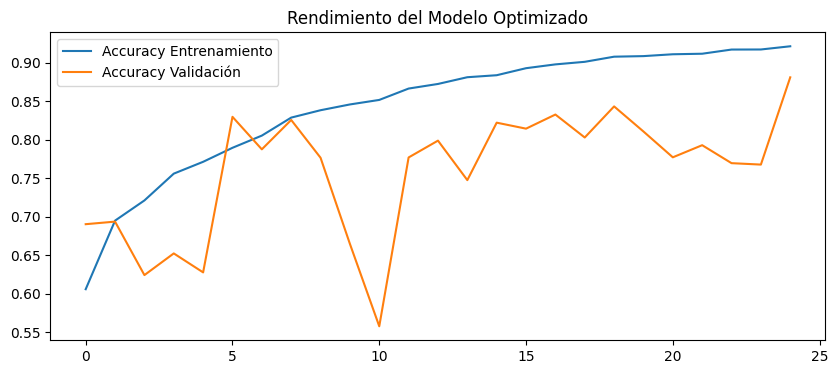

In [30]:
# Gráfica de resultados
plt.figure(figsize=(10,4))
plt.plot(history_opt.history['accuracy'], label='Accuracy Entrenamiento')
plt.plot(history_opt.history['val_accuracy'], label='Accuracy Validación')
plt.title("Rendimiento del Modelo Optimizado")
plt.legend()
plt.show()

In [31]:
## Evaluar el modelo con los datos de validación

test_loss, test_acc = model_optimized.evaluate(val_ds)
print(f"Precisión en el conjunto de validación: {test_acc * 100:.2f}%")


169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8811 - loss: 0.3457
Precisión en el conjunto de validación: 88.11%


## Conclusiones del Desarrollo

1.  **Modelo Base vs. Optimizado**: El modelo inicial logró una precisión aceptable, pero presentaba inestabilidad. La arquitectura optimizada, mediante el uso de **Global Average Pooling** y **Batch Normalization**, ha demostrado ser más robusta y alcanzar una precisión superior (88.11%) en el conjunto de validación.
2.  **Regularización**: La implementación de capas **Dropout** ha sido fundamental para reducir la brecha entre la precisión de entrenamiento y validación, mitigando el sobreajuste (overfitting).
3.  **Técnicas de Optimización**: El uso de un **Learning Rate** más bajo (0.0001) permitió una convergencia mucho más estable, evitando las fluctuaciones bruscas de pérdida observadas en versiones anteriores.
4.  **Aumento de Datos**: El **Data Augmentation** ayudó al modelo a generalizar mejor al exponerlo a variaciones de las imágenes satelitales (rotaciones y giros), lo cual es crítico dado que las fotos aéreas no tienen una orientación fija.

En resumen, la combinación de una arquitectura más profunda con técnicas de estabilización y regularización permite obtener un clasificador de uso práctico para imágenes de satélite.